In [ ]:
%pip install ultralytics -q
import cv2
import numpy as np
import matplotlib.pyplot as plt
import shutil
import zipfile
import torch
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

# Настройка отображения графиков
plt.rcParams['figure.figsize'] = [12, 8]


---
## 1. Подготовка датасета для YOLO


In [ ]:
file_id = "1KycQj4dik91RuBGvbhDJou7YDQEKAH2Z"
output_name = "MFSD.zip"
!gdown "https://drive.google.com/uc?id={file_id}" -O "{output_name}"

with zipfile.ZipFile(output_name, 'r') as zip_ref:
    zip_ref.extractall('/content/')
print(f"Скачано и распаковано: {output_name}")


Downloading...
From (original): https://drive.google.com/uc?id=1KycQj4dik91RuBGvbhDJou7YDQEKAH2Z
From (redirected): https://drive.google.com/uc?id=1KycQj4dik91RuBGvbhDJou7YDQEKAH2Z&confirm=t&uuid=c6e23c60-cdf1-4464-9461-04b4b52184b8
To: /content/MFSD.zip
100% 2.25G/2.25G [00:34<00:00, 65.0MB/s]
Скачано и распаковано: MFSD.zip


In [ ]:
IMAGES_DIR = Path('MSFD/1/face_crop')
MASKS_DIR = Path('MSFD/1/face_crop_segmentation')
OUTPUT_DIR = Path('dataset_yolo')

image_paths = sorted(IMAGES_DIR.glob('*.jpg'))
mask_paths = sorted(MASKS_DIR.glob('*.jpg'))

print(f'Найдено изображений: {len(image_paths)}')
print(f'Найдено масок: {len(mask_paths)}')



Найдено изображений: 9383
Найдено масок: 9383


In [ ]:
def convert_mask_to_yolo_polygon(mask_path: Path, class_id: int = 0) -> str | None:

    #Конвертирует бинарную маску в формат полигонов YOLO.

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None

    height, width = mask.shape

    # Бинаризация маски
    _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Поиск контуров
    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    largest_contour = max(contours, key=cv2.contourArea)

    if len(largest_contour) < 3:
        return None

    epsilon = 0.005 * cv2.arcLength(largest_contour, closed=True)
    approximated_contour = cv2.approxPolyDP(largest_contour, epsilon, closed=True)

    if len(approximated_contour) < 3:
        approximated_contour = largest_contour

    contour_points = approximated_contour.reshape(-1, 2)
    normalized_coords = []

    for x, y in contour_points:
        normalized_coords.extend([x / width, y / height])

    # Формирование строки в формате YOLO
    coord_string = ' '.join([f'{coord:.6f}' for coord in normalized_coords])
    return f'{class_id} {coord_string}'

# Тестирование функции конвертации
test_label = convert_mask_to_yolo_polygon(mask_paths[0])
print('Пример YOLO метки:')
print(test_label[:100] + '...' if test_label else 'Ошибка конвертации')


Пример YOLO метки:
0 0.000000 0.195062 0.000000 0.609877 0.324742 0.997531 0.608247 0.997531 0.863402 0.743210 0.889175...


In [ ]:
def create_yolo_dataset(
    images_dir: Path,
    masks_dir: Path,
    output_dir: Path,
    train_ratio: float = 0.8,
    random_seed: int = 42
) -> dict[str, int]:

    # Создаёт датасет в формате YOLO с разделением на train/val.

    output_path = Path(output_dir)

    # Очистка существующей директории
    if output_path.exists():
        shutil.rmtree(output_path)

    # Создание структуры директорий
    for split_name in ['train', 'val']:
        (output_path / split_name / 'images').mkdir(parents=True, exist_ok=True)
        (output_path / split_name / 'labels').mkdir(parents=True, exist_ok=True)

    # Загрузка списка изображений
    image_files = sorted(Path(images_dir).glob('*.jpg'))

    # Случайное перемешивание с фиксированным seed
    np.random.seed(random_seed)
    shuffled_indices = np.random.permutation(len(image_files))

    # Разделение на train и val
    train_size = int(len(image_files) * train_ratio)
    train_indices = shuffled_indices[:train_size]
    val_indices = shuffled_indices[train_size:]

    statistics = {'train': 0, 'val': 0, 'skipped': 0}

    # Обработка данных для каждого сплита
    splits_data = [
        ('train', train_indices),
        ('val', val_indices)
    ]

    for split_name, indices in splits_data:
        for idx in tqdm(indices, desc=f'Обработка {split_name}'):
            image_path = image_files[idx]
            mask_path = Path(masks_dir) / image_path.name

            # Проверка существования маски
            if not mask_path.exists():
                statistics['skipped'] += 1
                continue

            # Конвертация маски в формат YOLO
            yolo_label = convert_mask_to_yolo_polygon(mask_path)
            if yolo_label is None:
                statistics['skipped'] += 1
                continue

            # Копирование изображения
            shutil.copy(
                image_path,
                output_path / split_name / 'images' / image_path.name
            )

            # Сохранение метки
            label_filename = image_path.stem + '.txt'
            label_path = output_path / split_name / 'labels' / label_filename

            with open(label_path, 'w', encoding='utf-8') as f:
                f.write(yolo_label)

            statistics[split_name] += 1

    return statistics

# Создание датасета
print('Начало создания датасета YOLO...')
dataset_stats = create_yolo_dataset(IMAGES_DIR, MASKS_DIR, OUTPUT_DIR)
print('\nДатасет успешно создан!')
print(f"Обучающих примеров: {dataset_stats['train']}")
print(f"Валидационных примеров: {dataset_stats['val']}")
print(f"Пропущено файлов: {dataset_stats['skipped']}")


Начало создания датасета YOLO...


Обработка val: 100%|██████████| 1877/1877 [00:02<00:00, 882.85it/s] 


Датасет успешно создан!
Обучающих примеров: 7502
Валидационных примеров: 1877
Пропущено файлов: 4


In [ ]:
# Создание конфигурационного файла датасета
dataset_config = f"""path: {OUTPUT_DIR.absolute()}
train: train/images
val: val/images

names:
  0: mask
"""

config_path = OUTPUT_DIR / 'dataset.yaml'
with open(config_path, 'w', encoding='utf-8') as f:
    f.write(dataset_config.strip())

print('Конфигурационный файл dataset.yaml создан:')
print(dataset_config)


Конфигурационный файл dataset.yaml создан:
path: /content/dataset_yolo
train: train/images
val: val/images

names:
  0: mask



---
## 2. Обучение YOLO11-seg


In [ ]:
model = YOLO('yolo11n-seg.pt')

print('Модель YOLO11n-seg успешно загружена!')


Модель YOLO11n-seg успешно загружена!


In [ ]:
# Параметры обучения модели
training_results = model.train(
    data=str(OUTPUT_DIR / 'dataset.yaml'),
    epochs=50,
    imgsz=640,
    batch=8,
    patience=10,
    device=0,
    workers=2,
    project='runs',
    name='mask_seg'
)


Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=mask_seg2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=1

---
## 3. Тестирование модели


In [ ]:
#загрузка модели
best_model_path = 'runs/mask_seg2/weights/best.pt'
best_model = YOLO(best_model_path)

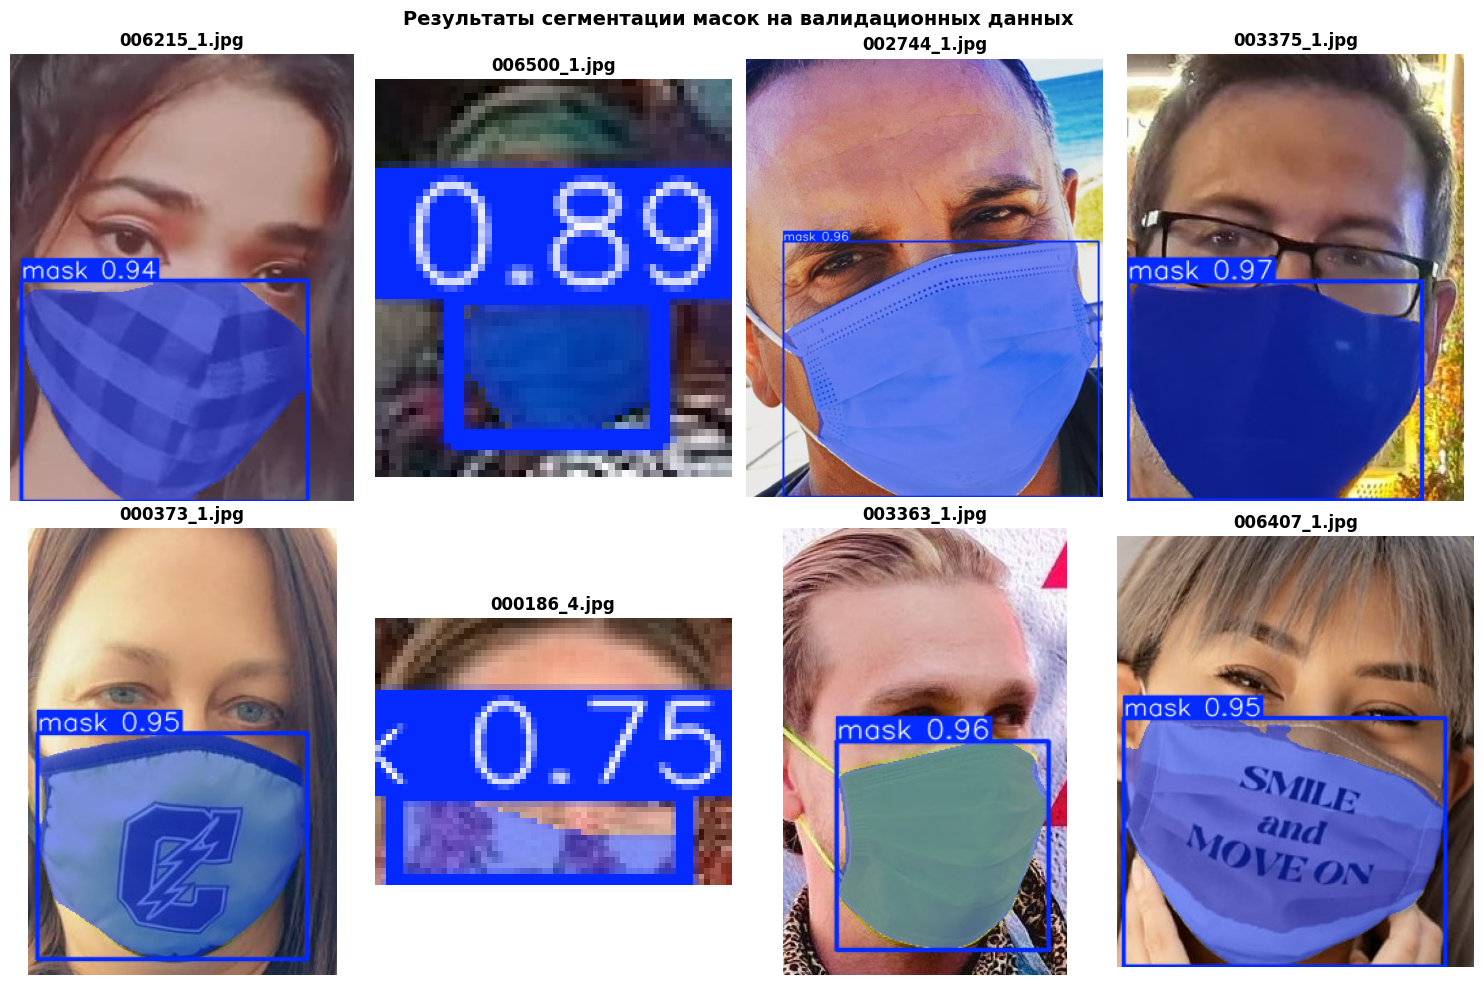

In [ ]:
# Тестирование на валидационных изображениях
val_image_paths = list((OUTPUT_DIR / 'val' / 'images').glob('*.jpg'))[:8]

fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten()

for idx, image_path in enumerate(val_image_paths):
    # Получение предсказаний модели
    predictions = best_model(str(image_path), verbose=False)
    result_image = predictions[0].plot()

    # Отображение результата
    axes[idx].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(image_path.name, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Результаты сегментации масок на валидационных данных',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


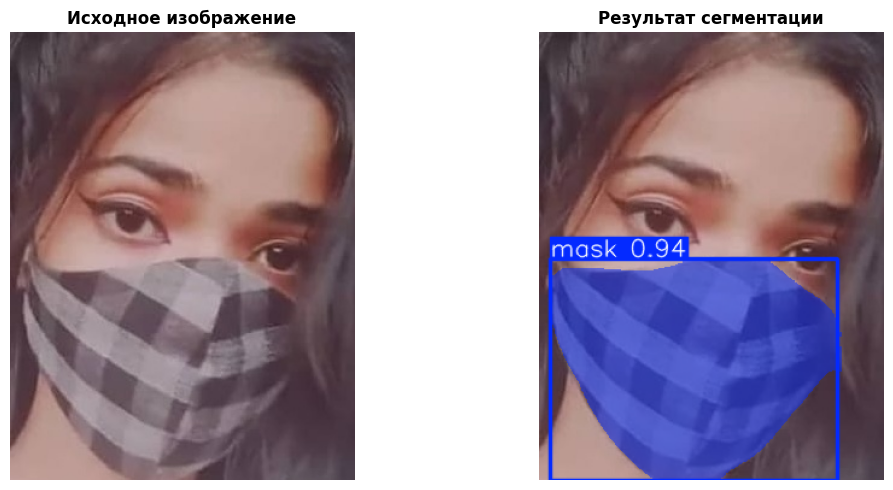

Найдено масок: 1


In [ ]:
def predict_mask_segmentation(image_path: Path, confidence_threshold: float = 0.5) -> None:
    # Выполняет сегментацию масок на произвольном изображении.

    # Получение предсказаний модели
    predictions = best_model(
        str(image_path),
        conf=confidence_threshold,
        verbose=False
    )

    # Загрузка и подготовка изображений для визуализации
    original_image = cv2.imread(str(image_path))
    original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    segmented_image = cv2.cvtColor(predictions[0].plot(), cv2.COLOR_BGR2RGB)

    # Создание визуализации
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(original_image_rgb)
    axes[0].set_title('Исходное изображение', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(segmented_image)
    axes[1].set_title('Результат сегментации', fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Подсчёт количества найденных масок
    num_masks = len(predictions[0].boxes) if predictions[0].boxes is not None else 0
    print(f'Найдено масок: {num_masks}')

# Тестирование функции на валидационном изображении
predict_mask_segmentation(val_image_paths[0])



--- Обработка: 114827560_612637226347903_2763860821287827135_n.jpg ---


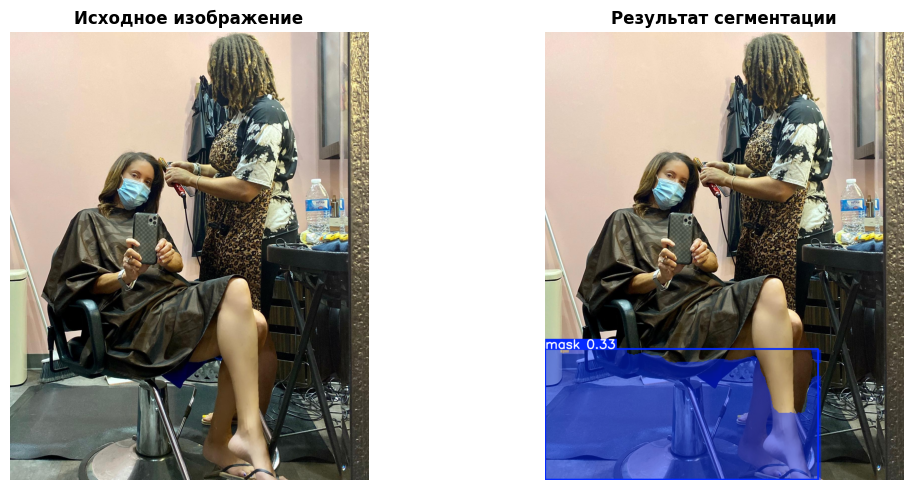

Найдено масок: 1

--- Обработка: 1234carlton_130217032_1269039916807375_8534704696144444690_n.jpg ---


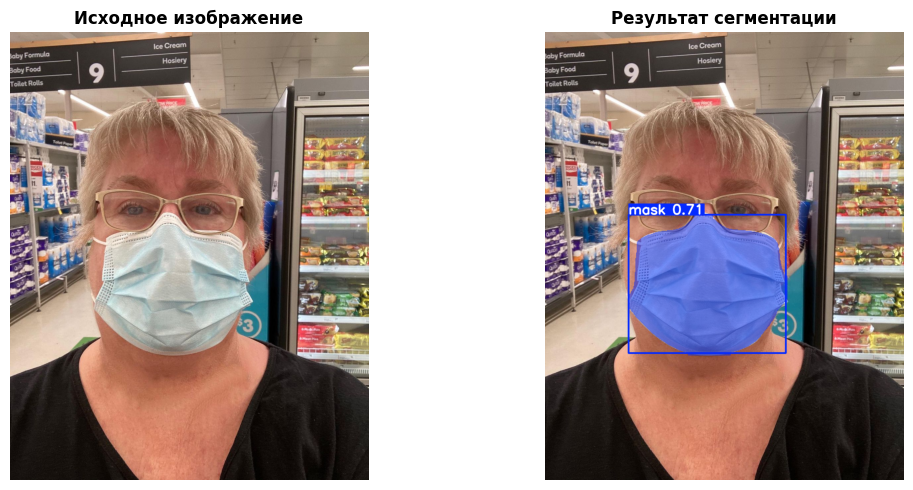

Найдено масок: 1

--- Обработка: 129421898_393248228586637_4979851665036615942_n.jpg ---


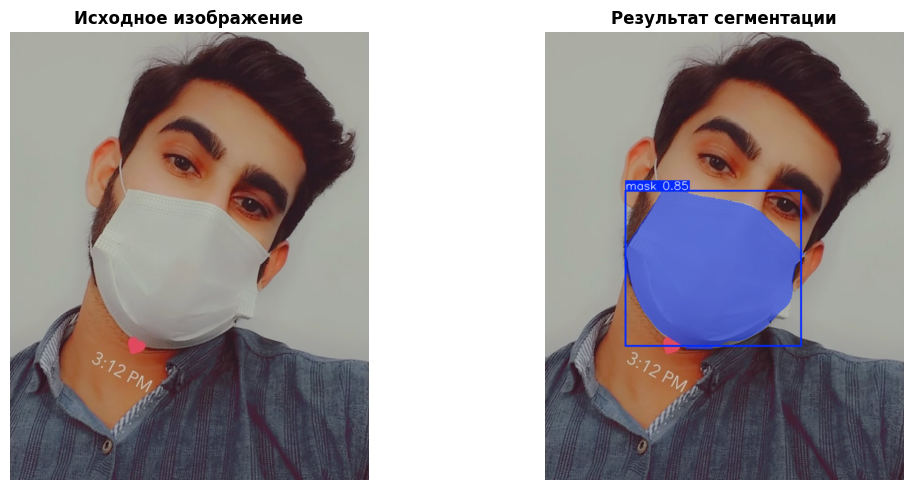

Найдено масок: 1

--- Обработка: 131556639_125546539680466_2522064222681575030_n.jpg ---


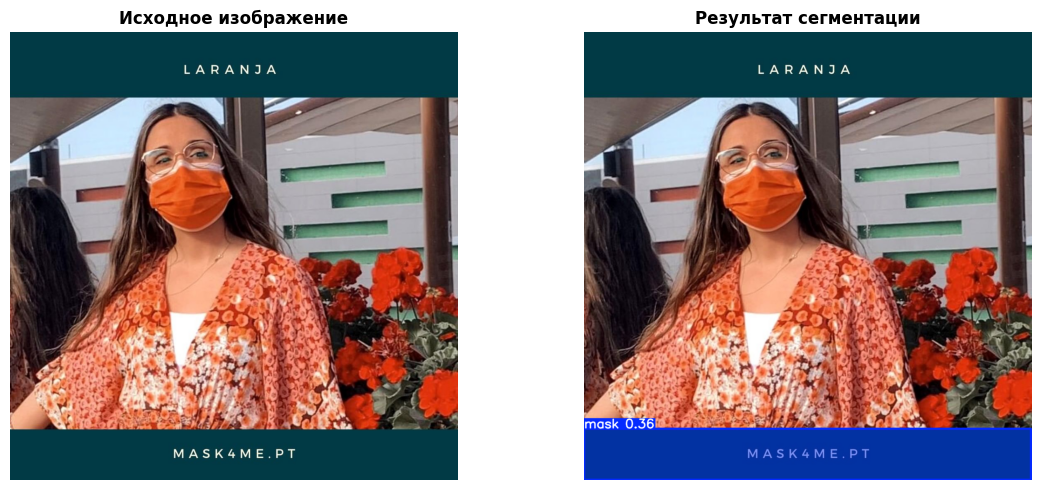

Найдено масок: 1

--- Обработка: 144083471_420353002379656_3196599189209606771_n.jpg ---


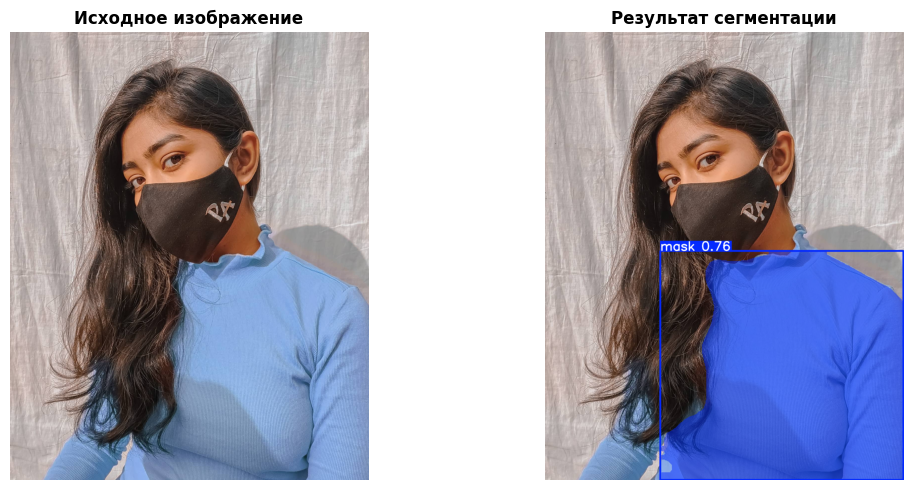

Найдено масок: 1

--- Обработка: 144169341_424281655295619_985180884240761776_n.jpg ---


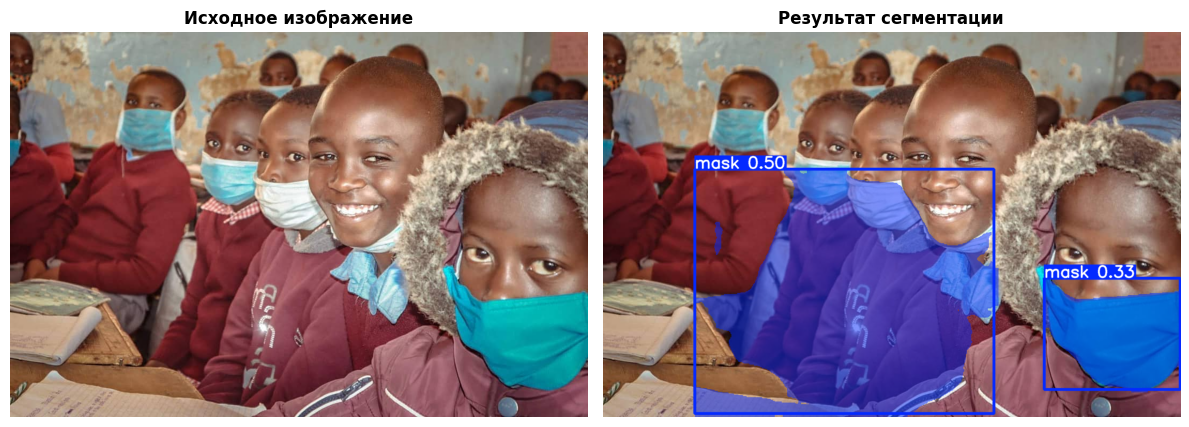

Найдено масок: 2

--- Обработка: 167593808_168567418448665_2098665313705176703_n.jpg ---


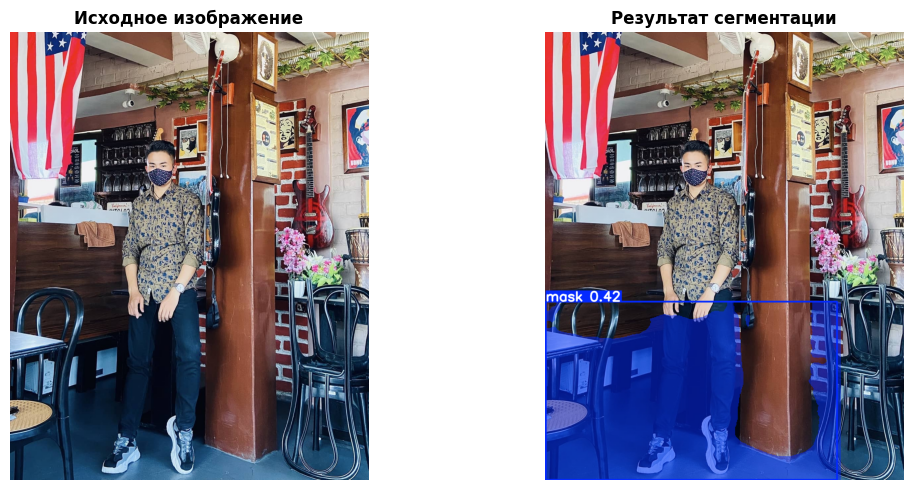

Найдено масок: 1

--- Обработка: 168622105_126656466144105_3969694588148735060_n.jpg ---


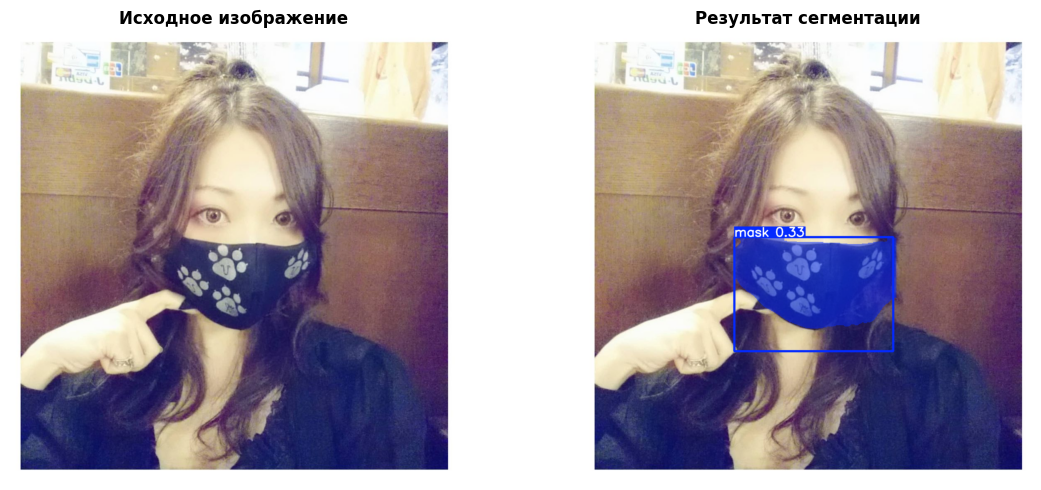

Найдено масок: 1


In [ ]:
# Тестирование на изображениях из другой директории
other_images_dir = Path('MSFD/2/img')
other_image_paths = sorted(other_images_dir.glob('*.jpg'))[:8]

for image_path in other_image_paths:
    print(f'\n--- Обработка: {image_path.name} ---')
    predict_mask_segmentation(image_path, confidence_threshold=0.3)
